ARTI308 - Machine Learning

# Lab 3: Exploratory Data Analysis (EDA)

EDA is the first and most important step in any Machine Learning project.
Before building models, we must understand:

- What does the data represent?
- Are there missing values?
- Are there outliers?
- What patterns exist?
- Which variables influence others?

If we do not understand the data, we cannot build a good model.

### Why EDA is Important

In real-world machine learning projects:

    1- 70–80% of the time is spent on understanding and cleaning data
    2- Only 20–30% is spent building models

**EDA helps us:**

- Detect errors
- Identify trends
- Discover relationships
- Make business decisions

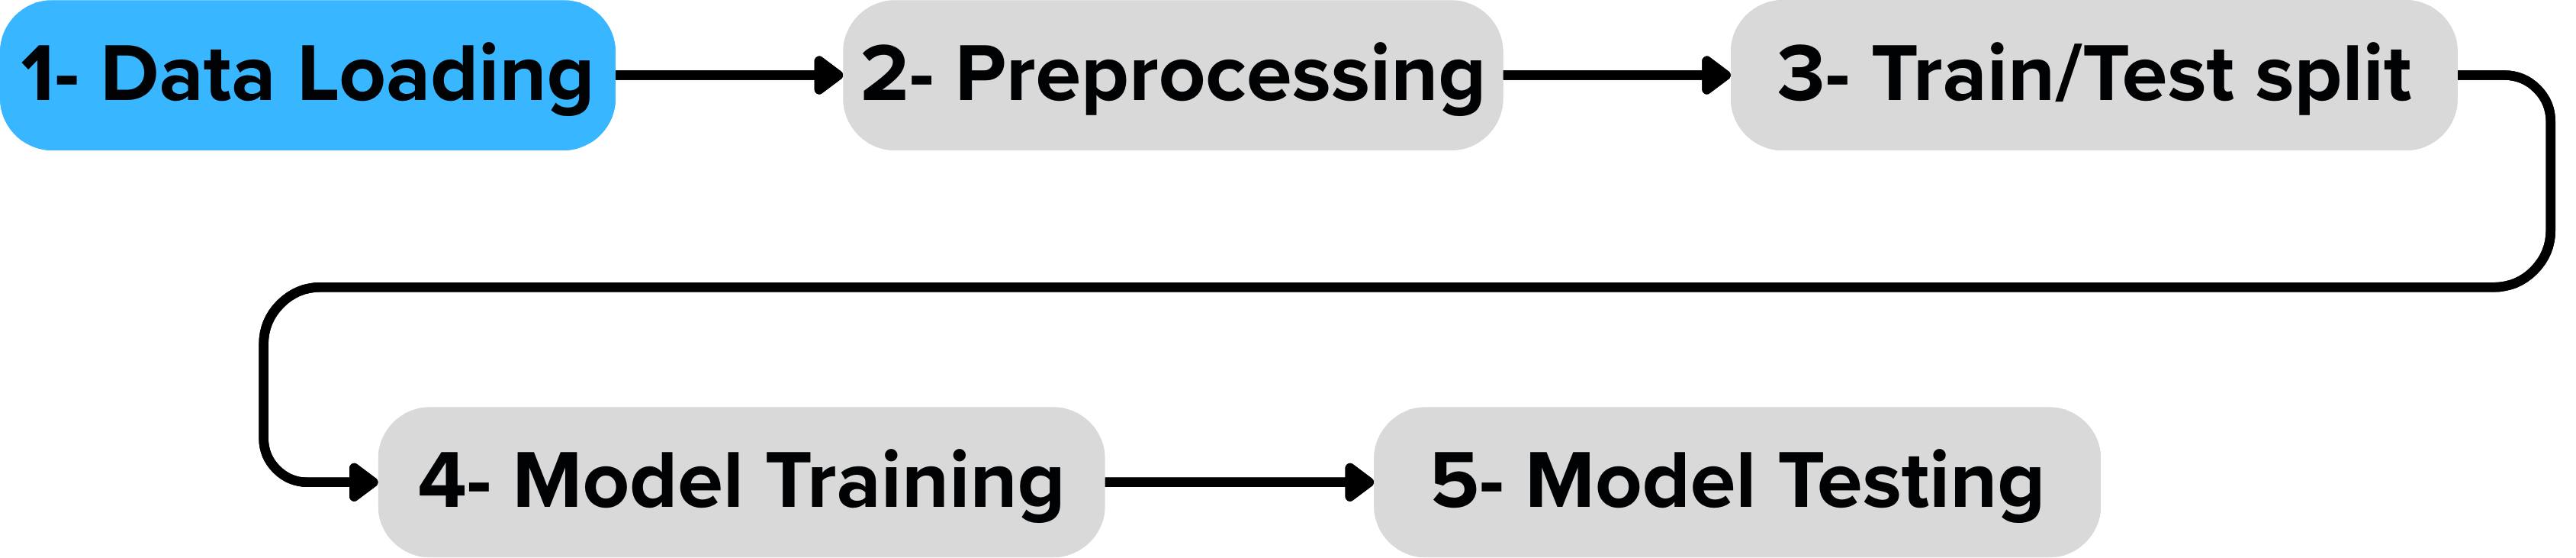

In [ ]:
# Import Libraries

import pandas as pd        # pandas: used for loading, manipulating, and analyzing tabular data (DataFrames)
import numpy as np         # numpy: used for numerical computations and array operations
import matplotlib.pyplot as plt  # matplotlib: used for creating static plots and charts
import seaborn as sns      # seaborn: built on matplotlib, provides higher-level, prettier statistical visualizations

# sns.set() applies a default seaborn theme to all matplotlib plots for cleaner styling
sns.set()

## Loading data in different ways
### Option 1: Load local CSV

In [ ]:
# Load Dataset

# pd.read_csv() reads a CSV file from disk and loads it into a DataFrame
df = pd.read_csv("Chocolate_Sales.csv")

# df.head(7) returns the first 7 rows of the DataFrame
# Useful for quickly inspecting the structure and sample values of the dataset
df.head(7)

The dataset consists of individual chocolate sales records, where each row represents a single sales transaction.
The columns describe attributes such as the sales date, product information, sales location, and sales amount.
From the first few rows, we can observe that some columns contain textual data, while others contain numerical values stored as text, such as currency values. This indicates that data type verification is necessary before further analysis.

### Option 2: Load online dataset using tensorflow.keras.datasets

In [ ]:
from tensorflow.keras import datasets  # Import the datasets module from Keras

# datasets.cifar10.load_data() downloads the CIFAR-10 image dataset automatically
# and returns it pre-split into training and testing sets
# train_images: 50,000 color images (32x32 pixels, 3 channels)
# train_labels: corresponding class labels (0–9) for training images
# test_images: 10,000 color images for evaluation
# test_labels: corresponding class labels for test images
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# .shape returns the dimensions of each array (samples, height, width, channels) or (samples, 1)
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

This example demonstrates how datasets can be loaded directly from online sources using built-in libraries. The CIFAR-10 dataset is downloaded automatically and provided in predefined training and testing sets. This approach is commonly used in supervised learning experiments, especially for image-based datasets, as it simplifies data access and preparation.

### Option 3: Kaggle-style path reading

In [ ]:
# train_df = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/train.csv")
# test_df  = pd.read_csv("/kaggle/input/rsna-breast-cancer-detection/test.csv")

# train_df.head()

### Data type of columns

In [ ]:
# df.dtypes returns the data type of each column in the DataFrame
# Common types: object (text/string), int64 (integer), float64 (decimal), datetime64 (dates)
# Helps detect columns that need type conversion before analysis
df.dtypes

The data type inspection shows that several columns are stored as object types, including date and monetary values. While categorical features are expected to be objects, date and numerical values stored as objects indicate formatting issues. Identifying such inconsistencies is important before proceeding with deeper analysis.

In [ ]:
# pd.to_datetime() converts the 'Date' column from string format to datetime objects
# This allows date-based operations like extracting month, year, or computing time differences
df['Date'] = pd.to_datetime(df['Date'])

# .replace() with regex=True removes '$' and ',' characters from the 'Amount' column
# regex=True enables pattern matching: [\$,] matches either '$' or ','
df['Amount'] = df['Amount'].replace('[\$,]', '', regex=True)

# pd.to_numeric() converts the cleaned 'Amount' strings into float64 numbers
# Required before any arithmetic operations (sum, mean, etc.) on this column
df['Amount'] = pd.to_numeric(df['Amount'])

# Verify that data types have been updated correctly
df.dtypes

The date column has been converted to a datetime format, and the revenue column has been cleaned and converted to a numerical data type. This ensures that time-based analysis and numerical calculations can be performed correctly. Correcting data types at this stage improves the reliability of subsequent analysis.

### Check Missing Values

In [ ]:
# df.isna() returns a boolean DataFrame: True where a value is missing (NaN), False otherwise
# .sum() counts the number of True values (missing entries) per column
# A count of 0 means the column has no missing values
print(df.isna().sum())

The missing values analysis shows whether any features contain null or undefined values.
If missing values are present, they can affect summary statistics and machine learning models.
In this dataset, the presence or absence of missing values helps determine whether data cleaning steps, such as imputation or row removal, will be required in later preprocessing stages.

### Check duplicate rows

In [ ]:
# df.duplicated() returns a boolean Series: True for rows that are exact duplicates of a previous row
# Filtering with [df.duplicated()==True] displays only the duplicate rows
# An empty result means no duplicate rows were found
df.duplicated()[df.duplicated()==True]

The duplicate records check identifies whether the same sales transaction appears more than once in the dataset.
Duplicate entries can bias the analysis by overrepresenting certain transactions or categories.
If duplicates exist, they should be investigated to determine whether they represent valid repeated transactions or data entry errors.

### No. of rows and columns

In [ ]:
# df.shape returns a tuple (rows, columns) representing the dimensions of the DataFrame
# shape[0] gives the number of rows (data samples)
# shape[1] gives the number of columns (features)
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

The dataset consists of 3,282 rows and 6 columns. This size is suitable for exploratory analysis and allows meaningful insights without being computationally expensive. Knowing the dataset dimensions helps in selecting appropriate analysis and visualization techniques.

### Descriptive summary Statistics

In [ ]:
# df.describe() generates summary statistics for all columns
# include='all' forces it to include both numerical and categorical columns
# For numerical columns: count, mean, std, min, 25%, 50%, 75%, max
# For categorical columns: count, unique (distinct values), top (most frequent), freq (its count)
df.describe(include='all')

The descriptive statistics provide an overview of both numerical and categorical features. Numerical summaries reveal the central tendency, spread, and range of values, while categorical summaries show the number of unique categories and their frequencies. This confirms that the dataset contains a limited number of numerical features and several categorical features, making it descriptive in nature.

### Univariate Analysis

In [ ]:
# plt.figure() creates a new figure; figsize=(8,5) sets its width and height in inches
plt.figure(figsize=(8,5))

# sns.histplot() draws a histogram showing how frequently each value range appears
# df['Boxes Shipped']: the column to visualize
# bins=20: divides the data range into 20 equally-spaced intervals (bars)
sns.histplot(df['Boxes Shipped'], bins=20)

# plt.title() adds a title to the plot
plt.title("Distribution of Boxes Shipped")

# plt.show() renders and displays the plot
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

The distribution of boxes shipped is right-skewed, indicating that most transactions involve a relatively small number of boxes, while a few transactions involve much larger shipments. Such skewness is common in sales data and may influence later modeling decisions.

### Distribution of Revenue

In [ ]:
plt.figure(figsize=(8,5))

# sns.histplot() on 'Amount' shows the frequency distribution of revenue values
# bins=20: splits revenue range into 20 intervals to reveal the spread and skew of sales amounts
sns.histplot(df['Amount'], bins=20)

plt.title("Distribution of Revenue")
plt.show()

The revenue distribution is also right-skewed, with most transactions generating moderate revenue and fewer transactions generating very high revenue. This suggests the presence of high-value sales that may act as outliers or important contributors to total revenue.

## Bivariate Analysis

### Revenue by Country

In [ ]:
# df.groupby('Country') groups all rows that share the same Country value
# ['Amount'].sum() then totals the revenue for each country group
# .sort_values(ascending=False) orders countries from highest to lowest revenue
country_revenue = df.groupby('Country')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

# .plot(kind='bar') draws a vertical bar chart from the Series
# Each bar represents one country; bar height = total revenue
country_revenue.plot(kind='bar')

plt.title("Total Revenue by Country")
plt.ylabel("Revenue")   # plt.ylabel() labels the y-axis
plt.show()

country_revenue

The total revenue varies across countries, with some countries contributing significantly more to overall sales than others. This indicates geographical differences in sales performance and suggests that country is an important categorical feature in the dataset.

### Revenue by Product

In [ ]:
# df.groupby('Product') groups rows by product name
# ['Amount'].sum() calculates total revenue per product
# .sort_values(ascending=False) ranks products from best to worst performing
product_revenue = df.groupby('Product')['Amount'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))

# Bar chart where each bar represents a product and its height shows total revenue
product_revenue.plot(kind='bar')

plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

product_revenue

The revenue distribution across products shows that certain chocolate products generate higher total revenue than others. This highlights product-level performance differences and suggests that product type plays a significant role in revenue generation.

### Revenue by Sales Person

In [ ]:
# df.groupby('Sales Person') groups rows by each salesperson's name
# ['Amount'].sum() computes total revenue generated by each salesperson
# .sort_values(ascending=False) ranks them from highest to lowest earner
salesperson_revenue = df.groupby('Sales Person')['Amount'].sum().sort_values(ascending=False)

# .head(10) returns only the top 10 salespersons to keep the output readable
salesperson_revenue.head(10)

The revenue contribution varies among salespersons, with a few individuals generating higher total revenue. This may reflect differences in sales regions, experience, or customer base, and indicates that the sales person feature may influence sales outcomes.

### Boxes vs Revenue Relationship

In [ ]:
plt.figure(figsize=(8,5))

# sns.scatterplot() places one dot per row on a 2D plane
# x='Boxes Shipped': horizontal axis (independent variable)
# y='Amount': vertical axis (dependent variable)
# data=df: the DataFrame to pull values from
# Used to visually inspect whether a relationship exists between the two variables
sns.scatterplot(x='Boxes Shipped', y='Amount', data=df)

plt.title("Boxes Shipped vs Revenue")
plt.show()

The scatter plot shows a general positive relationship between the number of boxes shipped and revenue. However, the spread of points indicates variability, suggesting that revenue is influenced by additional factors beyond shipment volume, such as product type or pricing.

### Correlation Matrix

In [ ]:
plt.figure(figsize=(6,4))

# df[['Boxes Shipped', 'Amount']].corr() computes the Pearson correlation matrix
# Values range from -1 (perfect negative) to +1 (perfect positive); 0 means no linear relationship
# sns.heatmap() displays the matrix as a color-coded grid
# annot=True overlays the actual correlation number inside each cell
sns.heatmap(df[['Boxes Shipped', 'Amount']].corr(), annot=True)

plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

The correlation matrix shows a weak positive correlation between boxes shipped and revenue. This suggests that while shipment volume contributes to revenue, it is not the sole determining factor. Other features likely play an important role in explaining revenue variation.

## Time-Based Analysis
### Monthly Revenue Trend

In [ ]:
# df['Date'].dt.to_period('M') extracts the year-month period from each date (e.g., 2022-01)
# This collapses daily dates into monthly buckets for aggregation
df['Month'] = df['Date'].dt.to_period('M')

# df.groupby('Month') groups all transactions that occurred in the same month
# ['Amount'].sum() computes total revenue for each month
monthly_revenue = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10,5))

# .plot() on a Series draws a line chart by default
# x-axis = Month periods, y-axis = total monthly revenue
# Reveals upward/downward trends and seasonal patterns over time
monthly_revenue.plot()

plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

The monthly revenue trend shows fluctuations over time, indicating seasonal or periodic variations in sales. Identifying such trends is useful for understanding business cycles and can inform forecasting and time-series modeling in future analysis.

# Assignment

In this assignment, you will apply the EDA techniques learned in class to a dataset of your choice. You must submit the dataset file with your notebook.


End of lab 3.